# Laboratorio 2 — LSTM
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git

## Ejercicio 1
### 1.1 Conjuntos de entrenamiento y prueba

Se utilizan dos de las series construidas en el Laboratorio 1: **Total mensual** y **Vía Aérea**. Se reconstruyen aplicando exactamente el mismo procedimiento del Laboratorio 1 (misma limpieza, misma exclusión del tipo de viajero con discontinuidad metodológica, mismo corte cronológico 70/30) para garantizar que los conjuntos de entrenamiento y prueba sean idénticos a los usados con los modelos ARIMA/Prophet/Holt-Winters del laboratorio anterior.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 100
SPLIT_DATE = pd.Timestamp("2021-04-01")

In [2]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)

Dimensiones: (161036, 13)


Se excluyen los registros con `Tipo de Viajero = "Viajero"` por la discontinuidad metodológica 2022-2023 documentada en el Laboratorio 1 (no aplica a Vía Marítima, pero esa serie no se usa en este ejercicio).

In [3]:
df_series = df[df["Tipo de Viajero"] != "Viajero"].copy()

def build_monthly(mask_df):
    mensual = mask_df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
    fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
    s = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas))
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    s.index.freq = "MS"
    return s

ts_total = build_monthly(df_series)
ts_aerea = build_monthly(df_series[df_series["Vía"] == "Aérea"])

series_dict = {
    "total": (ts_total, "Total mensual", "steelblue"),
    "aerea": (ts_aerea, "Vía Aérea", "darkcyan"),
}

for slug, (ts, titulo, _) in series_dict.items():
    print(f"{titulo:15s} inicio={ts.index[0]:%Y-%m} fin={ts.index[-1]:%Y-%m} n={len(ts)} freq={ts.index.freqstr}")

Total mensual   inicio=2009-01 fin=2026-06 n=210 freq=MS
Vía Aérea       inicio=2009-01 fin=2026-06 n=210 freq=MS


Se aplica el mismo corte cronológico 70/30 del Laboratorio 1 (entrenamiento = enero 2009 a marzo 2021, prueba = abril 2021 a junio 2026) a ambas series.

In [4]:
train_test = {}
for slug, (ts, titulo, color) in series_dict.items():
    train = ts[ts.index < SPLIT_DATE]
    test = ts[ts.index >= SPLIT_DATE]
    train_test[slug] = {"train": train, "test": test, "titulo": titulo, "color": color}
    print(f"{titulo:15s} -> entrenamiento: {len(train)} meses ({train.index[0]:%Y-%m} a {train.index[-1]:%Y-%m}), "
          f"prueba: {len(test)} meses ({test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})")

Total mensual   -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)
Vía Aérea       -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)


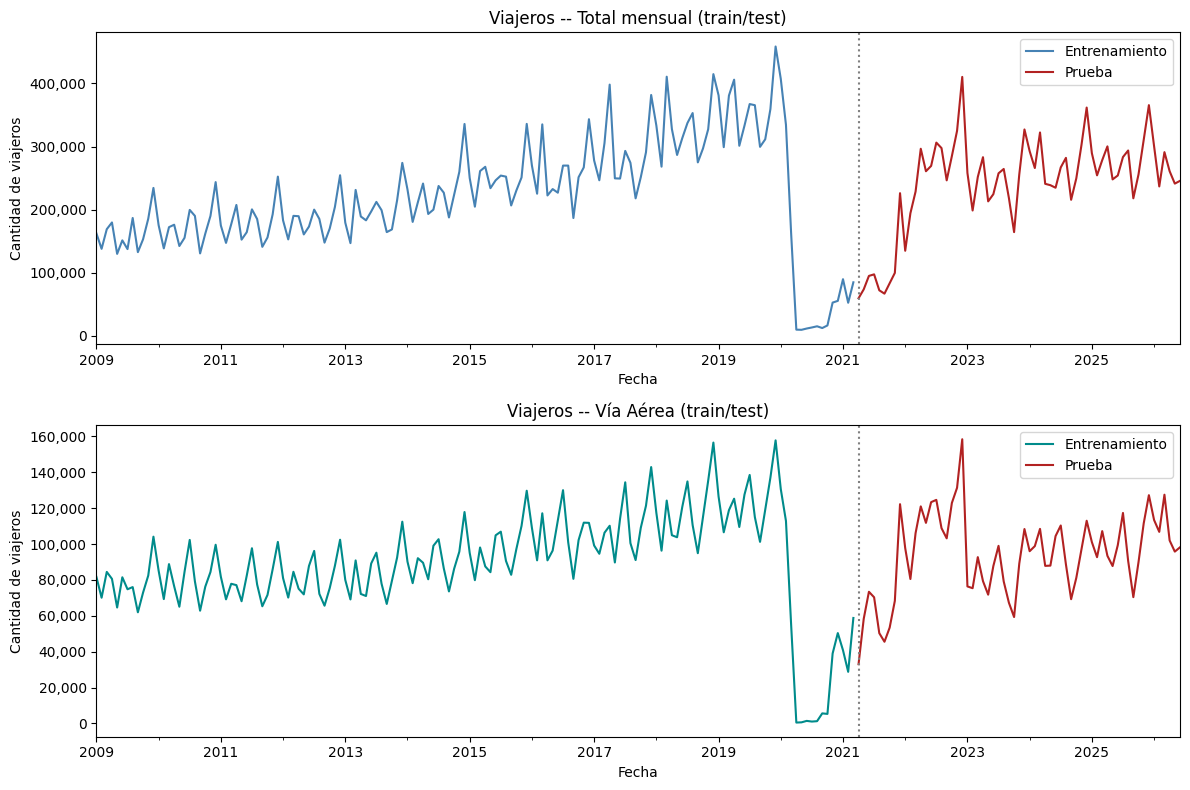

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color=d["color"], label="Entrenamiento")
    d["test"].plot(ax=ax, color="firebrick", label="Prueba")
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'Viajeros -- {d["titulo"]} (train/test)')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()